In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom import IQAEBinom
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [2]:
nShotUnit = 1
epsilon = 0.001
alpha = 0.05
nEstim = 10000
minRatio = 2

In [3]:
pTrue = 0.25
thetaTrue = np.arcsin(np.sqrt(pTrue))

In [5]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230830_IQAEVariousP_nShotUnit1/追加/results_IQAE_pTrue0.25_epsilon0001_alpha005.dat", 'rb') as p:
    results = pickle.load(p)

(array([0.000e+00, 0.000e+00, 0.000e+00, 1.300e+02, 1.720e+02, 8.600e+01,
        7.800e+01, 8.200e+01, 4.600e+01, 6.300e+01, 1.720e+02, 3.210e+02,
        7.560e+02, 7.060e+02, 8.420e+02, 1.374e+03, 1.303e+03, 1.262e+03,
        8.340e+02, 6.450e+02, 4.140e+02, 2.090e+02, 1.600e+02, 9.100e+01,
        7.100e+01, 6.000e+01, 4.400e+01, 2.400e+01, 2.200e+01, 1.800e+01,
        7.000e+00, 5.000e+00, 1.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]),
 array([100., 110., 120., 130., 140., 150., 160., 170., 180., 190., 200.,
        210., 220., 230., 240., 250., 260., 270., 280., 290., 300., 310.,
        320., 330., 340., 350., 360., 370., 380., 390., 400., 410., 420.,
        430., 440., 450., 460., 470.

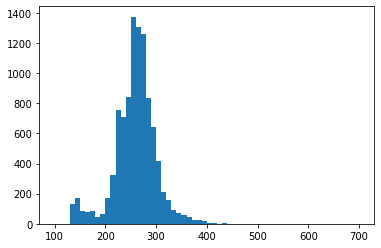

In [7]:
plt.hist([r["nGrover"][-1] for r in results], range=(100,700), bins=60)

In [8]:
# 次のroundに行く場合はNaNとする
nGrovers = np.arange(100, 451, 10)
numAng = 40
angleFracs = np.arange(1 / numAng / 2, 1, 1 / numAng)
resDf = pd.DataFrame(columns=["nGrover","r","AngleFrac","Bias","NumSamp","NumEnd"])

for nGrover in nGrovers:

    r = int((2 * nGrover + 1) * thetaTrue / np.pi)

    for angleFrac in angleFracs:
        print(nGrover, angleFrac, datetime.datetime.now())
        thetaTemp = (r + angleFrac) * np.pi / (2 * nGrover + 1)
        p = np.sin(thetaTemp) ** 2
        errs = []
        for i in range(nEstim):
            result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2)
            if result is None:
                errs.append(np.nan)
            else:
                pEst = result["Estimate"]
                errs.append(pEst - p)
                # if np.sum(np.logical_not(np.isnan(errThetas))) >= nSamp:
                #     break
        errMean = np.nanmean(errs)
        numSamp = len(errs)
        numEnd = numSamp - np.sum(np.isnan(errs))
        resDf = resDf.append(pd.Series([nGrover,r,angleFrac,errMean,numSamp,numEnd], index=resDf.columns), ignore_index=True)
        resDf.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/Bias_VariousNGrovAngleFrac_p0.25.csv", index=False)

100 0.0125 2023-11-09 15:21:50.218551


<ipython-input-8-4693ad731971>:25: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


100 0.037500000000000006 2023-11-09 15:21:58.623988
100 0.06250000000000001 2023-11-09 15:22:07.385258
100 0.08750000000000001 2023-11-09 15:22:19.148654
100 0.11250000000000002 2023-11-09 15:22:34.404675
100 0.13750000000000004 2023-11-09 15:22:54.544961
100 0.16250000000000003 2023-11-09 15:23:18.644040
100 0.18750000000000006 2023-11-09 15:23:39.800175
100 0.21250000000000005 2023-11-09 15:23:53.959228
100 0.23750000000000004 2023-11-09 15:24:04.953513
100 0.26250000000000007 2023-11-09 15:24:14.801041
100 0.2875000000000001 2023-11-09 15:24:25.747168
100 0.31250000000000006 2023-11-09 15:24:37.110200
100 0.3375000000000001 2023-11-09 15:24:49.397939
100 0.3625000000000001 2023-11-09 15:25:01.060085
100 0.38750000000000007 2023-11-09 15:25:08.454972
100 0.4125000000000001 2023-11-09 15:25:13.109054
100 0.4375000000000001 2023-11-09 15:25:16.921843
100 0.4625000000000001 2023-11-09 15:25:20.386136
100 0.4875000000000001 2023-11-09 15:25:23.621021
100 0.5125000000000001 2023-11-09 15:

In [18]:
resDf

,nGrover,r,AngleFrac,Bias,NumSamp,NumEnd
0,100.0,33.0,0.0125,NaN,10000.0,0.0
1,100.0,33.0,0.0375,NaN,10000.0,0.0
2,100.0,33.0,0.0625,NaN,10000.0,0.0
3,100.0,33.0,0.0875,NaN,10000.0,0.0
4,100.0,33.0,0.1125,NaN,10000.0,0.0
...,...,...,...,...,...,...
1435,450.0,150.0,0.8875,0.000071,10000.0,10000.0
1436,450.0,150.0,0.9125,0.000091,10000.0,10000.0
1437,450.0,150.0,0.9375,0.000101,10000.0,10000.0
1438,450.0,150.0,0.9625,0.000075,10000.0,10000.0


In [19]:
resDf["Bias"]

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
1435    0.000071
1436    0.000091
1437    0.000101
1438    0.000075
1439    0.000034
Name: Bias, Length: 1440, dtype: float64

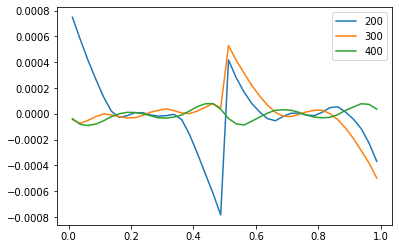

In [20]:
ax = plt.gca()
for nG in [200, 300, 400]:
    resDfPart = resDf[resDf["nGrover"] == nG]
    plt.plot(resDfPart["AngleFrac"], resDfPart["Bias"], label=str(nG))
plt.legend()
plt.show()

In [7]:
nGroversExp = np.array([r["nGrover"][-1] for r in results])
angleFracExp = np.modf((2 * nGroversExp + 1) * thetaTrue / np.pi)[0]

In [13]:
np.unique(nGroversExp, return_counts=True)

(array([131, 132, 134, 135, 137, 138, 140, 141, 143, 144, 146, 147, 149,
        150, 152, 153, 155, 156, 158, 159, 161, 162, 164, 165, 167, 168,
        170, 171, 173, 174, 176, 177, 179, 180, 182, 183, 185, 186, 188,
        189, 191, 192, 194, 195, 197, 198, 200, 201, 203, 204, 206, 207,
        209, 210, 212, 213, 215, 216, 218, 219, 221, 222, 224, 225, 227,
        228, 230, 231, 233, 234, 236, 237, 239, 240, 242, 243, 245, 246,
        248, 249, 251, 252, 254, 255, 257, 258, 260, 261, 263, 264, 266,
        267, 269, 270, 272, 273, 275, 276, 278, 279, 281, 282, 284, 285,
        287, 288, 290, 291, 293, 294, 296, 297, 299, 300, 302, 303, 305,
        306, 308, 309, 311, 312, 314, 315, 317, 318, 320, 321, 323, 324,
        326, 327, 329, 330, 332, 333, 335, 336, 338, 339, 341, 342, 344,
        345, 347, 348, 350, 351, 353, 354, 356, 357, 359, 360, 362, 363,
        365, 366, 368, 369, 372, 374, 375, 377, 378, 381, 383, 384, 386,
        387, 389, 390, 393, 395, 396, 398, 399, 401

In [14]:
# End num 少なすぎるところはNaNに
resDf_RemoveSmallNum = resDf.copy()
resDf_RemoveSmallNum["Bias"] = np.where(resDf_RemoveSmallNum["NumEnd"] < 1000, np.nan, resDf_RemoveSmallNum["Bias"])
biasMat = np.reshape(np.array(resDf_RemoveSmallNum["Bias"]), (len(nGrovers), len(angleFracs))).T

In [25]:
# matrixを補間
nGsInterp = np.arange(100, 450)

biasMatInterp = np.zeros((len(angleFracs), len(nGsInterp)))

for ingInterp in range(len(nGsInterp)):
    nGInterp = nGsInterp[ingInterp]
    ingOrg = np.abs(nGrovers - nGInterp).argmin()
    biasMatInterp[:,ingInterp] = biasMat[:,ingOrg]

In [16]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

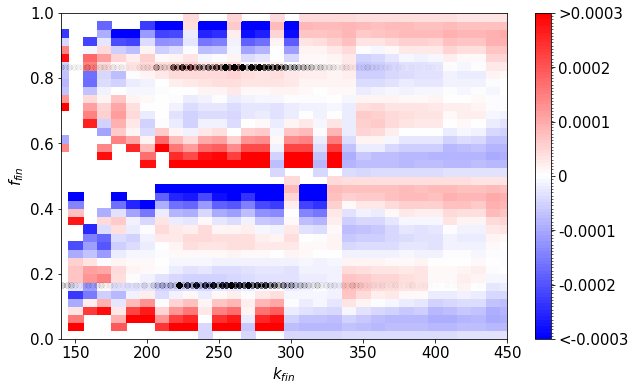

In [28]:
fig, ax = plt.subplots(figsize=(10,6))
levels = MaxNLocator(nbins=100).tick_values(-0.0003, 0.0003)
cmap = plt.colormaps['bwr']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
heatmap = ax.pcolor(nGsInterp, angleFracs, biasMatInterp, cmap="bwr", norm=norm)
cbar = fig.colorbar(heatmap, ax=ax) # カラーバー

ticks  = np.arange(-0.0003, 0.00031, 0.0001)
labels = ['<-0.0003', '-0.0002', '-0.0001', '0', '0.0001', '0.0002', '>0.0003']
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)
cbar.ax.tick_params(axis='y', labelsize=15)

ax.scatter(nGroversExp,angleFracExp, c="k", alpha=0.005)
ax.set_ylim(0,1)
ax.set_xlim(140,450)
ax.set_xlabel("$k_{fin}$", fontsize=15)
ax.set_ylabel("$f_{fin}$", fontsize=15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

In [29]:
errs = [r["Estimate"] - pTrue for r in results]
print(np.mean(errs))
print(np.std(errs))

3.4942265258393448e-06
0.0001585265705992215
